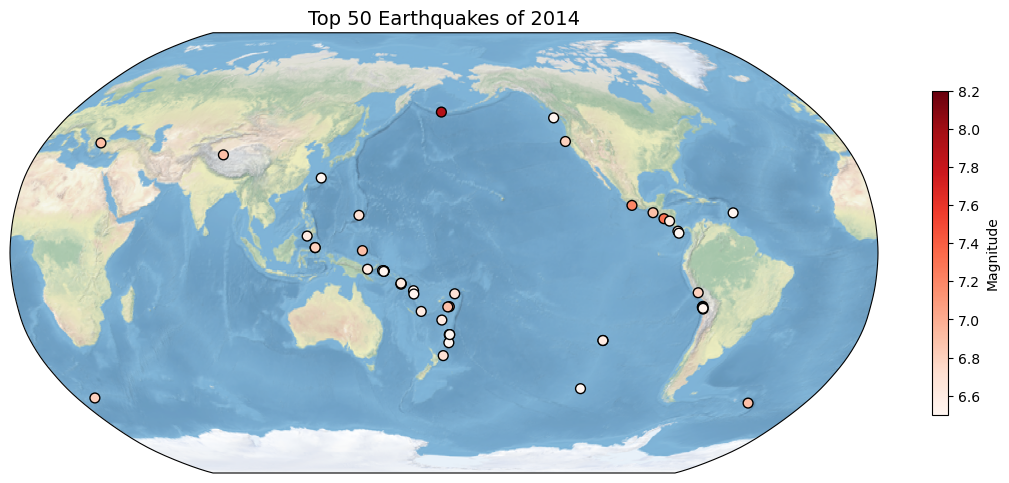

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 加载数据集
earthquakes_data = pd.read_csv("C:/Users/xiezhengyang/Desktop/usgs_earthquakes.csv")

# 根据震级筛选前50大地震
top_50_earthquakes = earthquakes_data.nlargest(50, 'mag')

# 设置画布和地图投影 (使用罗宾森投影，中心经度设为180度)
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))

# 添加地图背景
ax.set_global()
ax.stock_img()  # 添加类似卫星图像的背景

# 绘制地震点的散点图
scatter = ax.scatter(
    top_50_earthquakes['longitude'],
    top_50_earthquakes['latitude'],
    c=top_50_earthquakes['mag'],
    cmap='Reds',
    s=50,
    edgecolor='black',
    transform=ccrs.PlateCarree(),
    zorder=3,
)

# 添加颜色条
cbar = plt.colorbar(scatter, orientation='vertical', shrink=0.6, pad=0.05)
cbar.set_label('Magnitude')

# 添加标题
plt.title('Top 50 Earthquakes of 2014', fontsize=14)

# 显示地图
plt.show()

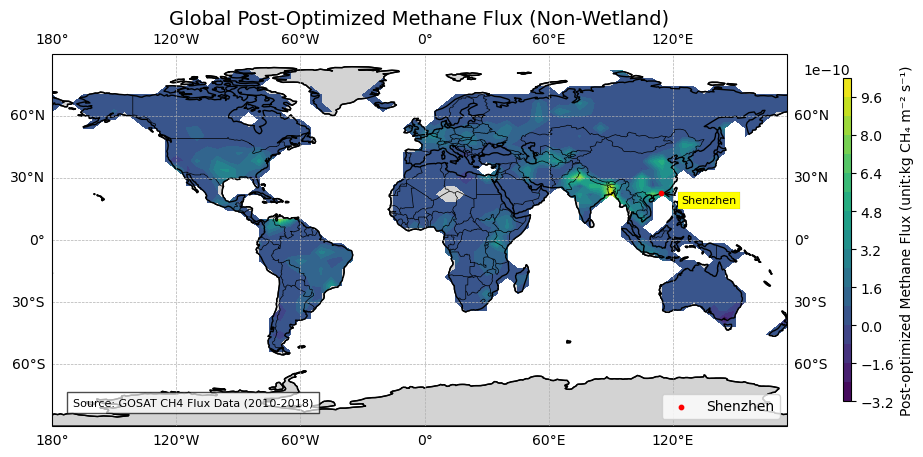

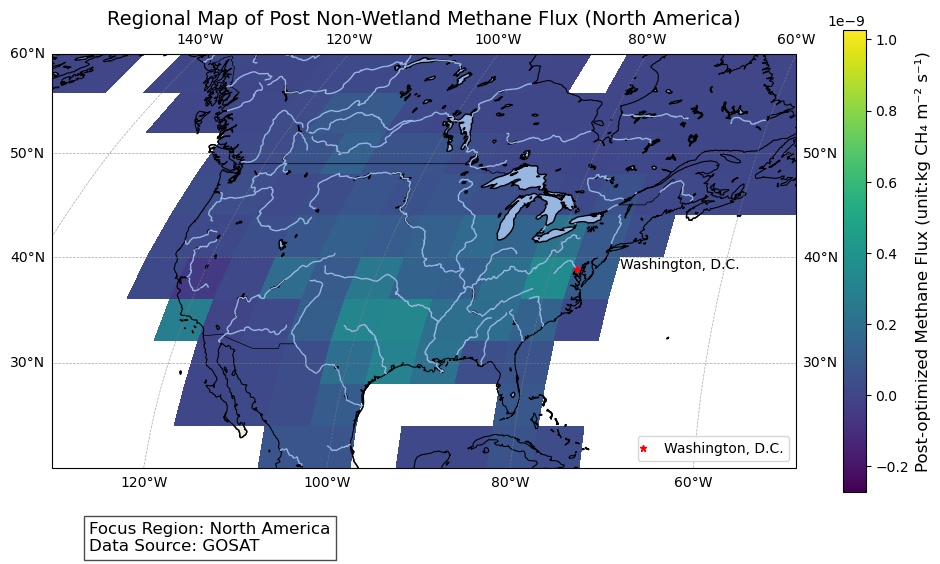

In [2]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# 加载数据集
data = xr.open_dataset('C:/Users/xiezhengyang/Desktop/GlobalInv_GOSAT_CH4Flux_2010-2018_v1.nc')

# 提取变量和坐标
variable = data['post_nonwetland']

# 定义投影并设置画布
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 绘制数据，设置颜色映射并包含颜色条
plot = ax.contourf(
    data['lon'], data['lat'], variable, 
    levels=20, cmap='viridis', transform=ccrs.PlateCarree()
)
cbar = plt.colorbar(plot, orientation='vertical', pad=0.06, aspect=40, shrink=0.7)
cbar.set_label('Post-optimized Methane Flux (unit:kg CH₄ m⁻² s⁻¹)', fontsize=10)

# 添加网格线、标题和标签
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
ax.set_title('Global Post-Optimized Methane Flux (Non-Wetland)', fontsize=14)

# 添加地理特征
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='k')

# 将深圳的位置添加到地图上
shenzhen_coords = (114.0579, 22.5431)  # 深圳的经度、纬度

# 添加深圳的标注
plt.scatter(*shenzhen_coords, color='red', s=10, label='Shenzhen', zorder=5)
plt.annotate(
    'Shenzhen',
    xy=shenzhen_coords,
    xytext=(shenzhen_coords[0] + 10, shenzhen_coords[1] - 5),
    bbox=dict(boxstyle='square', fc='yellow', linewidth=0.05),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=8,
    color='black'
)

# 添加注释框
plt.text(
    -170, -80, 'Source: GOSAT CH4 Flux Data (2010-2018)', fontsize=8,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.7)
)

plt.legend(loc='lower right')
plt.show()

# 创建区域地图（北美），使用不同的投影 (Robinson投影)
proj = ccrs.Robinson() 
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-130, -60, 20, 60], crs=ccrs.PlateCarree())  # 北美的经度/纬度范围

# 添加标签
ax.set_xlabel("Longitude", fontsize=12, labelpad=20)
ax.set_ylabel("Latitude", fontsize=12, labelpad=40)

# 绘制数据 
im = ax.pcolormesh(data['lon'], data['lat'], variable, transform=ccrs.PlateCarree(), cmap='viridis')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.LAKES, edgecolor='black')
ax.add_feature(cfeature.RIVERS)

# 添加网格线
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = True  
gl.right_labels = True  
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# 标记华盛顿特区
dc_lon, dc_lat = -77.0369, 38.9072
ax.plot(dc_lon, dc_lat, marker='*', color='red', markersize=5, transform=ccrs.PlateCarree(), label='Washington, D.C.')
ax.text(dc_lon + 5, dc_lat, 'Washington, D.C.', transform=ccrs.PlateCarree(), color='black', fontsize=10)

# 添加标题、颜色条和注释
plt.title("Regional Map of Post Non-Wetland Methane Flux (North America)", fontsize=14)
cbar = plt.colorbar(im, orientation='vertical', pad=0.05)
cbar.set_label("Post-optimized Methane Flux (unit:kg CH₄ m⁻² s⁻¹)", fontsize=12)
# 添加文本框注释
ax.text(
    0.05,-0.2, "Focus Region: North America\nData Source: GOSAT",
    transform=ax.transAxes,fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)

# 显示地图
plt.legend(loc='lower right',
           scatterpoints=1,
           handlelength=0, 
           handletextpad=1.5
)
plt.show()